In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from datasets import load_dataset
from lapsum.topk import soft_topk
from PIL import Image
from transformers import AutoImageProcessor, AutoModel

from classae.eval.posthoc_M import build_posthoc_M
from classae.sae.batch_topk import BatchTopKSAE
from classae.sae.classae import ClasSAE

In [2]:
sae = ClasSAE.from_pretrained("../checkpoints/dino/classae_4096/")

sae.eval()

ClasSAE(
  (decoder): Linear(in_features=4096, out_features=768, bias=False)
  (encoder): Linear(in_features=768, out_features=4096, bias=True)
)

In [3]:
@torch.no_grad()
def plot_feature_class_table(model, max_classes=None):
    M = model.calculate_M().cpu().numpy()  # [d, C]
    k = M.sum(axis=1)  # k_i per feature

    row_order = np.argsort(k)  # specialists -> generalists
    M, k = M[row_order], k[row_order]

    col_order = np.argsort(-M.sum(axis=0))  # busiest classes first
    if max_classes:
        col_order = col_order[:max_classes]
    M = M[:, col_order]

    fig, (ax_m, ax_k) = plt.subplots(
        1, 2, figsize=(12, 7), gridspec_kw={"width_ratios": [8, 1]}, sharey=True
    )
    im = ax_m.imshow(M, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    ax_m.set_xlabel("classes (reordered by claimed mass)")
    ax_m.set_ylabel(r"features (sorted by $k_i$)")
    ax_m.set_title("Learned feature–class table $M$")
    fig.colorbar(im, ax=ax_m, fraction=0.03, pad=0.02)

    ax_k.barh(range(len(k)), k, color="darkorange")
    ax_k.invert_yaxis()  # keep row 0 (smallest k_i) at the top
    ax_k.set_xlabel(r"$k_i$")
    ax_k.set_title("budget")

    plt.tight_layout()
    return fig

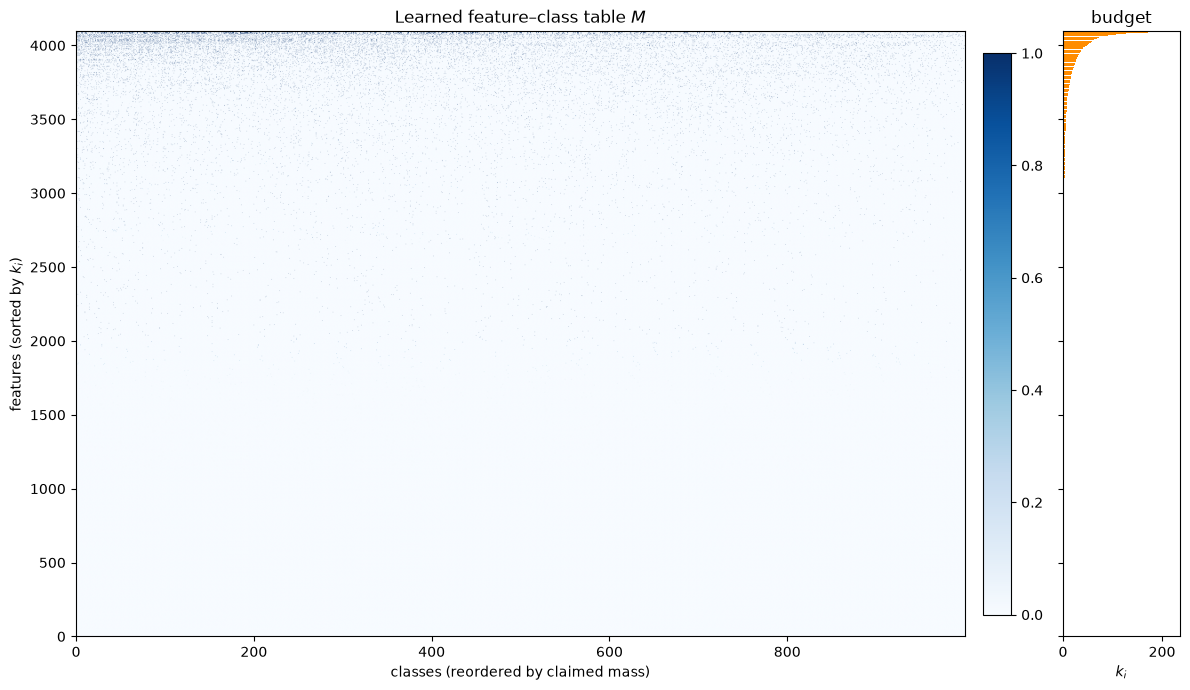

In [4]:
fig = plot_feature_class_table(sae)

Text(0.5, 0, 'log10(k_i)')

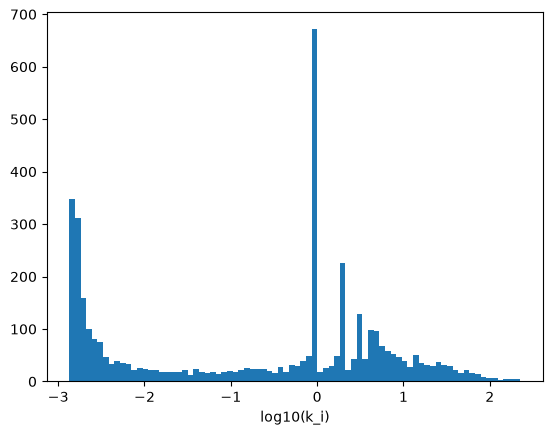

In [5]:
k = sae.calculate_M().sum(dim=1).detach().cpu().numpy()
k.min()

# plt.hist(np.log10(k + 1e-6), bins=80)
plt.hist(np.log10(k + 1e-6), bins=80)
# plt.hist(np.log10(k + 1e-6), bins=80)
plt.xlabel("log10(k_i)")

In [6]:
# ---- config ----
DINO_CKPT = "facebook/dinov3-vitb16-pretrain-lvd1689m"  # swap for the exact repo id you're using
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---- load DINOv3 backbone ----
processor = AutoImageProcessor.from_pretrained(DINO_CKPT)
dino = AutoModel.from_pretrained(DINO_CKPT).to(DEVICE).eval()

# DINOv3 prepends 1 CLS token + some register tokens before the patch tokens;
# check dino.config for the exact count (e.g. num_register_tokens) rather than assuming 0.
NUM_PREFIX_TOKENS = 1 + getattr(dino.config, "num_register_tokens", 0)
PATCH_SIZE = dino.config.patch_size

# ---- load an ImageNet-1k val image from HF ----
ds = load_dataset(
    "ILSVRC/imagenet-1k", split="validation"
)  # gated: needs HF auth token


@torch.no_grad()
def dino_patch_tokens(pil_image):
    inputs = processor(images=pil_image, return_tensors="pt").to(DEVICE)
    out = dino(**inputs)
    tokens = out.last_hidden_state[0, NUM_PREFIX_TOKENS:]  # [num_patches, dino_dim]
    h, w = inputs["pixel_values"].shape[-2:]
    grid_h, grid_w = h // PATCH_SIZE, w // PATCH_SIZE
    assert (
        tokens.shape[0] == grid_h * grid_w
    ), "prefix-token count assumption is wrong — check config"
    return tokens, grid_h, grid_w, inputs["pixel_values"][0]


@torch.no_grad()
def class_agreement_heatmap(classae_model, pil_image, class_idx):
    tokens, grid_h, grid_w, pixel_values = dino_patch_tokens(pil_image)
    tokens = tokens.to(next(classae_model.parameters()).device)

    # same soft encode used at training time, just fed patches instead of pooled vectors
    f = classae_model.encode(tokens)
    k_hat = (f > 0).sum(dim=-1)
    weights = soft_topk(f, k_hat.float().unsqueeze(1), 0.001)
    pi = weights / k_hat.unsqueeze(-1)  # [num_patches, d], each row on the simplex
    M = classae_model.calculate_M()  # [d, C]
    s_c = pi @ M[:, class_idx]  # [num_patches]

    heat = s_c.reshape(grid_h, grid_w).float().cpu()
    heat = (heat - heat.min()) / (
        heat.max() - heat.min() + 1e-8
    )  # per-image contrast stretch for display
    return heat, pixel_values


def overlay(pil_image, heat, upsample_size, alpha=0.45):
    heat_up = F.interpolate(
        heat[None, None], size=upsample_size, mode="bilinear", align_corners=False
    )[0, 0].numpy()
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(pil_image.resize(upsample_size[::-1]))
    ax.imshow(heat_up, cmap="inferno", alpha=alpha)
    ax.axis("off")
    return fig


@torch.no_grad()
def find_specialists_for_class(
    classae_model, class_idx, k_max=3.0, claim_thresh=0.3, top_n=4
):
    """Return indices of dictionary features that (a) claim `class_idx` substantially
    and (b) have a small total budget k_i, i.e. are near-dedicated to a handful of classes.
    """
    M = classae_model.calculate_M()  # [d, C]
    k = M.sum(dim=1)  # [d]
    claim = M[:, class_idx]  # how much of feature i's budget goes to this class

    mask = (k <= k_max) & (claim >= claim_thresh)
    candidates = torch.nonzero(mask, as_tuple=True)[0]
    if candidates.numel() == 0:
        raise ValueError(
            f"No specialists found for class {class_idx} with k_max={k_max}, "
            f"claim_thresh={claim_thresh} — loosen the thresholds."
        )
    order = torch.argsort(claim[candidates], descending=True)
    return candidates[order][:top_n], k, claim


@torch.no_grad()
def specialist_patch_maps(classae_model, tokens, feature_indices):
    """Per-feature soft selection mass at every patch, for a chosen set of features."""
    f = classae_model.encode(tokens)
    k_hat = (f > 0).sum(dim=-1)
    weights = soft_topk(f, k_hat.float().unsqueeze(1), 0.001)
    return weights[:, feature_indices]  # [num_patches, len(feature_indices)]


def plot_specialists_for_class(
    classae_model,
    pil_image,
    class_idx,
    k_max=3.0,
    claim_thresh=0.3,
    top_n=4,
    alpha=0.45,
    panel_size=4.0,
):
    tokens, grid_h, grid_w, pixel_values = dino_patch_tokens(pil_image)
    tokens = tokens.to(next(classae_model.parameters()).device)

    feat_idx, k, claim = find_specialists_for_class(
        classae_model, class_idx, k_max=k_max, claim_thresh=claim_thresh, top_n=top_n
    )
    maps = specialist_patch_maps(
        classae_model, tokens, feat_idx
    ).cpu()  # [num_patches, top_n]

    upsample_size = pixel_values.shape[-2:]
    display_img = pil_image.resize(upsample_size[::-1])

    n_panels = len(feat_idx) + 1  # + 1 combined panel, stacked below the specialists
    fig, axes = plt.subplots(n_panels, 1, figsize=(panel_size, panel_size * n_panels))
    if (
        n_panels == 1
    ):  # only happens if find_specialists_for_class returned a single feature
        axes = [axes]

    combined = torch.zeros(grid_h * grid_w)
    for j, ax in enumerate(axes[:-1]):
        heat = maps[:, j].reshape(grid_h, grid_w)
        combined += maps[:, j] * claim[feat_idx[j]].item()

        heat_norm = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
        heat_up = F.interpolate(
            heat_norm[None, None],
            size=upsample_size,
            mode="bilinear",
            align_corners=False,
        )[0, 0].numpy()

        ax.imshow(display_img)
        ax.imshow(heat_up, cmap="inferno", alpha=alpha)
        ax.set_title(
            f"feat {feat_idx[j].item()}  (k_i={k[feat_idx[j]].item():.1f})", fontsize=10
        )
        ax.axis("off")

    combined_heat = combined.reshape(grid_h, grid_w)
    combined_norm = (combined_heat - combined_heat.min()) / (
        combined_heat.max() - combined_heat.min() + 1e-8
    )
    combined_up = F.interpolate(
        combined_norm[None, None],
        size=upsample_size,
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()

    axes[-1].imshow(display_img)
    axes[-1].imshow(combined_up, cmap="inferno", alpha=alpha)
    axes[-1].set_title(f"combined ({len(feat_idx)} specialists)", fontsize=10)
    axes[-1].axis("off")

    fig.suptitle(
        f"Specialist features serving class {class_idx}", y=1.0 + 0.15 / n_panels
    )
    plt.tight_layout()
    return fig


@torch.no_grad()
def specialist_hard_selection(classae_model, tokens, feature_indices):
    """Binary mask: did feature j actually make it into the hard top-k̂ selection
    at each patch? Using the real hard mask (not a quantile threshold) means this
    matches what the model actually does at inference, with no threshold to tune."""
    encoded_acts = classae_model.encode(tokens)  # [num_patches, d]
    return (
        encoded_acts[:, feature_indices] > 0
    ).float()  # [num_patches, len(feature_indices)]


def plot_specialist_support_count(
    classae_model,
    pil_image,
    class_idx,
    k_max=3.0,
    claim_thresh=0.3,
    top_n=6,
    alpha=0.55,
    upsample_mode="nearest",
):
    tokens, grid_h, grid_w, pixel_values = dino_patch_tokens(pil_image)
    tokens = tokens.to(next(classae_model.parameters()).device)

    feat_idx, k, claim = find_specialists_for_class(
        classae_model, class_idx, k_max=k_max, claim_thresh=claim_thresh, top_n=top_n
    )
    active = specialist_hard_selection(
        classae_model, tokens, feat_idx
    ).cpu()  # [num_patches, n_feats]
    counts = active.sum(dim=1)  # [num_patches], integer-valued
    count_map = counts.reshape(grid_h, grid_w)

    n_feats = len(feat_idx)
    upsample_size = pixel_values.shape[-2:]
    display_img = pil_image.resize(upsample_size[::-1])

    # nearest, not bilinear: counts are discrete, interpolating them fabricates
    # fractional "votes" that don't correspond to anything real
    count_up = F.interpolate(
        count_map[None, None].float(), size=upsample_size, mode=upsample_mode
    )[0, 0].numpy()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(display_img)
    cmap = plt.get_cmap("viridis", n_feats + 1)  # discrete bins: 0, 1, ..., n_feats
    im = ax.imshow(count_up, cmap=cmap, vmin=-0.5, vmax=n_feats + 0.5, alpha=alpha)
    ax.set_title(f"specialists supporting class {class_idx}  ({n_feats} candidates)")
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax, ticks=range(n_feats + 1), fraction=0.046, pad=0.04)
    cbar.set_label("# specialists selecting this patch")
    plt.tight_layout()
    return fig, count_map, feat_idx

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

In [7]:
@torch.no_grad()
def find_specialists_by_mean_activation(classae_model, tokens, class_idx,
                                         k_max=3.0, claim_thresh=0.3, top_n=6,
                                         M_override=None):
    """
    M_override : optional torch.Tensor or np.ndarray, shape [d, num_classes]
        If given, used in place of classae_model.calculate_M() — e.g. an M
        computed at a different alpha_M, a checkpoint from an earlier step,
        or a hand-edited/ablated matrix. Must already be on the same feature
        indexing as the SAE (row i = feature i), and moved to the same device
        as the model's own tensors internally.
    """
    if M_override is not None:
        M = M_override
        if isinstance(M, np.ndarray):
            M = torch.from_numpy(M)
        M = M.to(dtype=torch.float32, device=next(classae_model.parameters()).device)
    else:
        M = classae_model.calculate_M()                 # [d, C]

    d = tokens.shape[-1] if False else None  # (not used — left out to avoid confusion with M's own shape)
    expected_d = classae_model.dict_size if hasattr(classae_model, "dict_size") else M.shape[0]
    if M.shape[0] != expected_d:
        raise ValueError(
            f"M_override has {M.shape[0]} feature rows, but the SAE has "
            f"{expected_d} — check you're not passing a transposed matrix."
        )

    k = M.sum(dim=1)
    claim = M[:, class_idx]

    relevant = (k <= k_max) & (claim >= claim_thresh)
    relevant_idx = torch.nonzero(relevant, as_tuple=True)[0]
    if relevant_idx.numel() == 0:
        raise ValueError(
            f"No specialists found for class {class_idx} with k_max={k_max}, "
            f"claim_thresh={claim_thresh} — loosen the thresholds."
        )

    sae_latent = classae_model.encode(tokens)   # [num_patches, d]
    mean_act = sae_latent.float().mean(dim=0)                        # [d]

    candidate_means = mean_act[relevant_idx]
    n_top = min(top_n, relevant_idx.numel())
    top_vals, top_local = torch.topk(candidate_means, k=n_top, largest=True, sorted=True)
    top_feat_idx = relevant_idx[top_local]

    return top_feat_idx, top_vals, sae_latent, k, claim


def plot_top_specialists_by_activation(classae_model, pil_image, class_idx,
                                        k_max=3.0, claim_thresh=0.3, top_n=6,
                                        alpha=0.5, panel_size=4.0, M_override=None):
    tokens, grid_h, grid_w, pixel_values = dino_patch_tokens(pil_image)
    tokens = tokens.to(next(classae_model.parameters()).device)
    upsample_size = pixel_values.shape[-2:]
    display_img = pil_image.resize(upsample_size[::-1])

    feat_idx, mean_vals, sae_latent, k, claim = find_specialists_by_mean_activation(
        classae_model, tokens, class_idx, k_max=k_max, claim_thresh=claim_thresh,
        top_n=top_n, M_override=M_override,
    )
    sae_latent = sae_latent.cpu()

    feature_grids = [
        sae_latent[:, f].reshape(grid_h, grid_w).numpy() for f in feat_idx
    ]
    global_vmin = min(g.min() for g in feature_grids)
    global_vmax = max(g.max() for g in feature_grids)
    if np.isclose(global_vmin, global_vmax):
        global_vmax = global_vmin + 1e-8

    n_panels = len(feat_idx)
    fig, axes = plt.subplots(n_panels, 1, figsize=(panel_size, panel_size * n_panels))
    if n_panels == 1:
        axes = [axes]

    for ax, f, grid, mean_val in zip(axes, feat_idx, feature_grids, mean_vals):
        heat_t = torch.from_numpy(grid)[None, None].float()
        heat_up = F.interpolate(heat_t, size=upsample_size, mode="bilinear", align_corners=False)[0, 0].numpy()

        ax.imshow(display_img)
        im = ax.imshow(heat_up, cmap="hot", alpha=alpha, vmin=global_vmin, vmax=global_vmax)
        ax.set_title(
            f"feat {f.item()}  (k_i={k[f].item():.1f}, "
            f"claim={claim[f].item():.2f}, mean_act={mean_val.item():.3f})",
            fontsize=9,
        )
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    src = "external M" if M_override is not None else "model's M"
    fig.suptitle(f"Top {n_panels} specialists for class {class_idx} ({src}), ranked by mean activation", y=1.02)
    plt.tight_layout()
    return fig, feat_idx, mean_vals



admiral


(<Figure size 400x4800 with 24 Axes>,
 tensor([3501, 2488,  480, 1021, 1030, 1900, 2268, 1179, 1874, 2947, 3992, 1895],
        device='cuda:0'),
 tensor([0.9798, 0.7569, 0.4781, 0.2947, 0.2124, 0.1587, 0.1194, 0.0811, 0.0388,
         0.0282, 0.0173, 0.0000], device='cuda:0'))

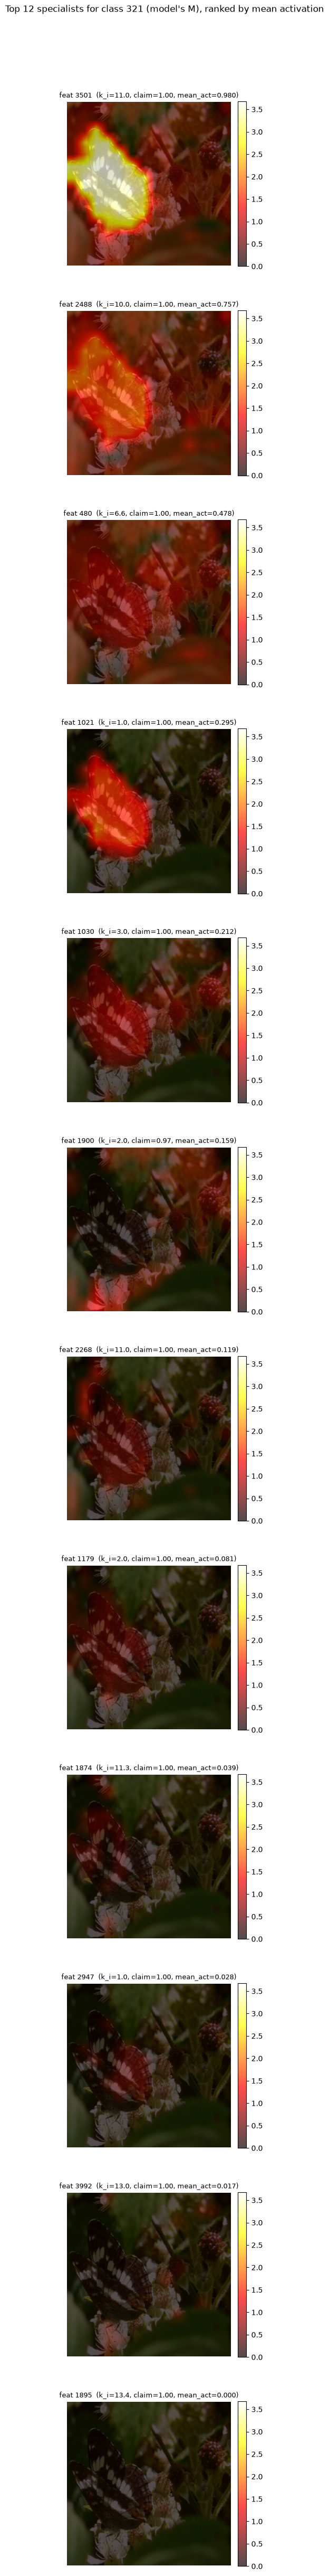

In [8]:
from classae.labels import IMAGENET2012_CLASSES

sample = ds[1204]
image = sample["image"].convert("RGB")
true_label = sample["label"]

print(list(IMAGENET2012_CLASSES.values())[true_label])

plot_top_specialists_by_activation(
    sae, image, class_idx=true_label, claim_thresh=0.9, top_n=30, k_max=15, alpha=0.7
)